In [ ]:
pip install pandas pyodbc sqlalchemy matplotlib seaborn openpyxl

In [16]:
import pandas as pd
import pyodbc
from sqlalchemy import create_engine
from urllib.parse import quote_plus

server = r"jerry\MSSQLSERVER01"   
database = "EmadeDev"

odbc_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

connection_string = "mssql+pyodbc:///?odbc_connect=" + quote_plus(odbc_str)

engine = create_engine(connection_string)

with engine.connect() as conn:
    print("Connected to EmadeDev successfully")

Connected to EmadeDev successfully


1. Setup + Load Excel → SQL Server

In [23]:
import pandas as pd
import pyodbc
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import matplotlib.pyplot as plt

# =========================
# CONNECTION CONFIG
# =========================
server = r"JERRY\MSSQLSERVER01"
database = "EmadeDev"

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={quote_plus(conn_str)}")

# =========================
# LOAD EXCEL
# =========================
file_path = r"C:\Users\HP\Documents\EMADE\Python_Training\NetflixBusiness\NetflixBusiness.xlsx"
df = pd.read_excel(file_path)

# =========================
# DATA CLEANING
# =========================
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df.fillna({
    "director": "Unknown",
    "cast": "Unknown",
    "country": "Unknown",
    "rating": "Not Rated",
    "duration": "0",
    "listed_in": "Unknown",
    "description": "No Description"
}, inplace=True)

df.drop_duplicates(inplace=True)

# convert date
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# =========================
# LOAD TO SQL SERVER
# =========================
df.to_sql("Netflix", con=engine, if_exists="replace", index=False)

print("✅ Data loaded successfully into SQL Server")

✅ Data loaded successfully into SQL Server


In [24]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


 ANALYSIS + CHARTS (15 QUESTIONS)
 1. Movies vs TV Shows

      type  count
0  TV Show   2676
1    Movie   6131


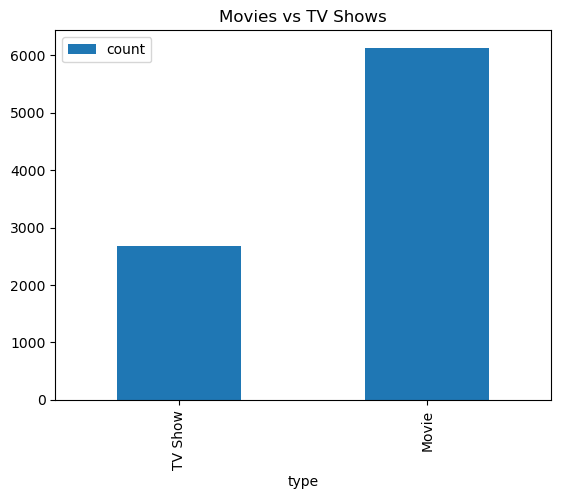

In [25]:
q1 = pd.read_sql("SELECT type, COUNT(*) count FROM Netflix GROUP BY type", engine)
print(q1)

q1.plot(kind='bar', x='type', y='count', title='Movies vs TV Shows')
plt.show()

2. Most Common Rating

  rating  count
0  TV-MA   3207
1  TV-14   2160
2  TV-PG    863
3      R    799
4  PG-13    490


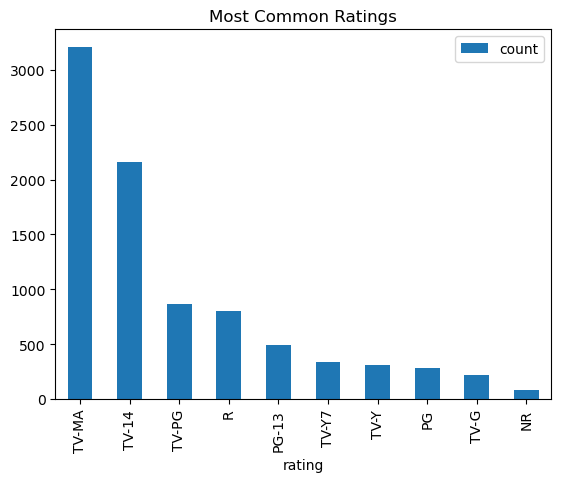

In [26]:
q2 = pd.read_sql("""
SELECT rating, COUNT(*) count 
FROM Netflix 
GROUP BY rating 
ORDER BY count DESC
""", engine)

print(q2.head())

q2.head(10).plot(kind='bar', x='rating', y='count', title='Most Common Ratings')
plt.show()

3. Movies in 2020

In [27]:
q3 = pd.read_sql("""
SELECT * FROM Netflix 
WHERE release_year = 2020 AND type = 'Movie'
""", engine)

print(q3)

    show_id   type                                              title  \
0        s1  Movie                               Dick Johnson Is Dead   
1       s17  Movie  Europe's Most Dangerous Man: Otto Skorzeny in ...   
2       s79  Movie                                     Tughlaq Durbar   
3       s85  Movie                               Omo Ghetto: the Saga   
4      s104  Movie                                     Shadow Parties   
..      ...    ...                                                ...   
512   s3047  Movie                      All the Freckles in the World   
513   s3061  Movie                                      Ghost Stories   
514   s5973  Movie                                   #cats_the_mewvie   
515   s7595  Movie                 Norm of the North: Family Vacation   
516   s8100  Movie                                        Straight Up   

                                              director  \
0                                      Kirsten Johnson   
1      

4. Top 5 Countries

          country  count
0   United States   2818
1           India    972
2         Unknown    831
3  United Kingdom    419
4           Japan    245


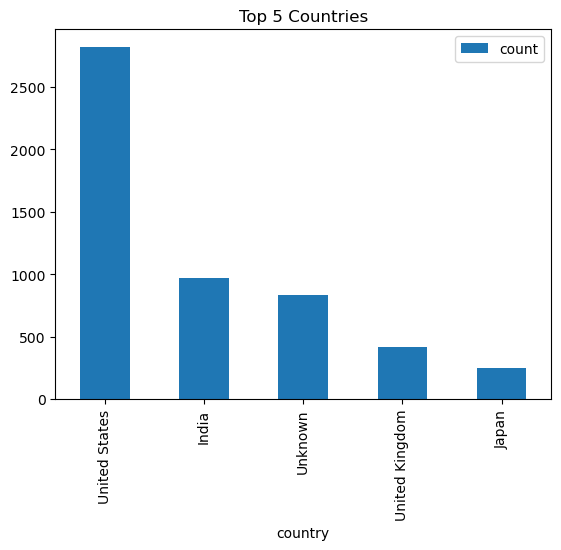

In [28]:
q4 = pd.read_sql("""
SELECT TOP 5 country, COUNT(*) count
FROM Netflix
GROUP BY country
ORDER BY count DESC
""", engine)

print(q4)

q4.plot(kind='bar', x='country', y='count', title='Top 5 Countries')
plt.show()

5. Longest Movie

In [29]:
df_sql = pd.read_sql("SELECT * FROM Netflix", engine)

movies = df_sql[df_sql['type'] == 'Movie'].copy()
movies['duration_int'] = movies['duration'].str.extract('(\d+)').astype(float)

longest = movies.sort_values(by='duration_int', ascending=False).head(1)
print(longest[['title', 'duration']])

                           title duration
4253  Black Mirror: Bandersnatch  312 min


6. Content Added Last 5 Years

    show_id     type                          title          director  \
0        s1    Movie           Dick Johnson Is Dead   Kirsten Johnson   
1        s2  TV Show                  Blood & Water           Unknown   
2        s3  TV Show                      Ganglands   Julien Leclercq   
3        s4  TV Show          Jailbirds New Orleans           Unknown   
4        s5  TV Show                   Kota Factory           Unknown   
..      ...      ...                            ...               ...   
889    s890    Movie        The Woman in the Window        Joe Wright   
890    s891  TV Show                    Castlevania           Unknown   
891    s892    Movie                     Layer Cake    Matthew Vaughn   
892    s893    Movie       Tottaa Pataaka Item Maal  Aditya Kripalani   
893    s894    Movie  Wave of Cinema: Filosofi Kopi   Adriano Rudiman   

                                                  cast         country  \
0                                              Un

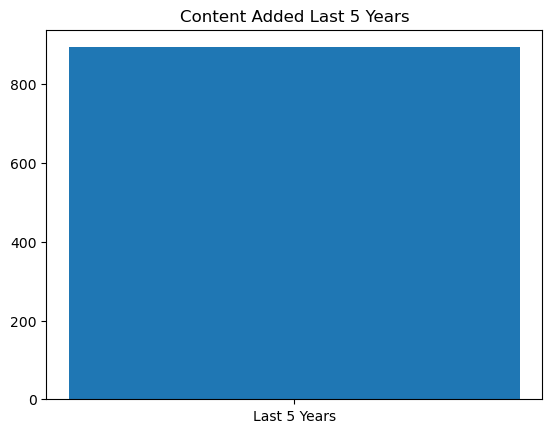

In [30]:
recent = df_sql[df_sql['date_added'] >= (pd.Timestamp.now() - pd.DateOffset(years=5))]
print(recent)

recent_count = recent.shape[0]

plt.bar(['Last 5 Years'], [recent_count])
plt.title("Content Added Last 5 Years")
plt.show()

7. Director Rajiv Chilaka

In [31]:
q7 = df_sql[df_sql['director'].str.contains("Rajiv Chilaka", na=False)]
print(q7)

     show_id   type                                              title  \
401     s423  Movie                     Chhota Bheem: Journey to Petra   
407     s407  Movie                       Chhota Bheem - Neeli Pahaadi   
408     s408  Movie                              Chhota Bheem & Ganesh   
409     s409  Movie                 Chhota Bheem & Krishna: Mayanagari   
410     s410  Movie  Chhota Bheem & Krishna: Pataliputra- City of t...   
411     s411  Movie                 Chhota Bheem And The Broken Amulet   
412     s412  Movie             Chhota Bheem And The Crown of Valhalla   
413     s413  Movie               Chhota Bheem and the Incan Adventure   
414     s414  Movie                Chhota Bheem and The ShiNobi Secret   
415     s415  Movie                           Chhota Bheem Aur Hanuman   
416     s416  Movie                           Chhota Bheem aur Krishna   
417     s417  Movie                Chhota Bheem aur Krishna vs Zimbara   
420     s420  Movie                   

8. TV Shows > 5 Seasons

In [32]:
tv = df_sql[df_sql['type'] == 'TV Show'].copy()
tv['seasons'] = tv['duration'].str.extract('(\d+)').astype(float)

q8 = tv[tv['seasons'] > 5]
print(q8)

     show_id     type                          title         director  \
8         s9  TV Show  The Great British Baking Show  Andy Devonshire   
55       s56  TV Show                      Nailed It          Unknown   
66       s66  TV Show                   Numberblocks          Unknown   
68       s68  TV Show              Saved by the Bell          Unknown   
82       s83  TV Show                        Lucifer          Unknown   
...      ...      ...                            ...              ...   
8189   s8190  TV Show         The Andy Griffith Show          Unknown   
8378   s8379  TV Show                     The L Word          Unknown   
8442   s8443  TV Show              The Office (U.S.)          Unknown   
8557   s8558  TV Show                  The West Wing          Unknown   
8710   s8711  TV Show                          Weeds          Unknown   

                                                   cast  \
8     Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...   
55   

9. Content per Genre

listed_in
 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     774
 Independent Movies        736
 TV Dramas                 696
 Romantic Movies           613
Name: count, dtype: int64


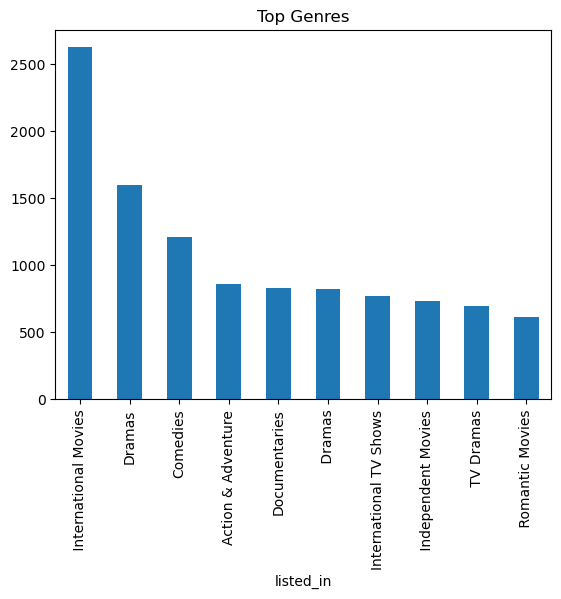

In [33]:
genre = df_sql.copy()
genre = genre.assign(listed_in=genre['listed_in'].str.split(',')).explode('listed_in')

q9 = genre['listed_in'].value_counts().head(10)
print(q9)

q9.plot(kind='bar', title='Top Genres')
plt.show()

10. India Avg Releases per Year (Top 5)

    release_year  count
52          2017    111
53          2018    101
54          2019     93
51          2016     80
55          2020     77


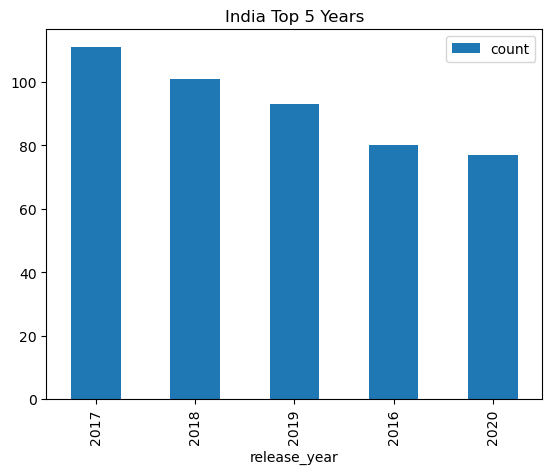

In [34]:
india = df_sql[df_sql['country'].str.contains("India", na=False)]

q10 = india.groupby('release_year').size().reset_index(name='count')
q10 = q10.sort_values(by='count', ascending=False).head(5)

print(q10)

q10.plot(kind='bar', x='release_year', y='count', title='India Top 5 Years')
plt.show()

11. Documentary Movies

In [35]:
q11 = df_sql[
    (df_sql['type'] == 'Movie') &
    (df_sql['listed_in'].str.contains("Documentaries", na=False))
]

print(q11)

     show_id   type                                              title  \
0         s1  Movie                               Dick Johnson Is Dead   
16       s17  Movie  Europe's Most Dangerous Man: Otto Skorzeny in ...   
45       s46  Movie                             My Heroes Were Cowboys   
69       s69  Movie                                         Schumacher   
88       s89  Movie           Blood Brothers: Malcolm X & Muhammad Ali   
...      ...    ...                                                ...   
8739   s8740  Movie                 Why We Fight: The Battle of Russia   
8744   s8745  Movie                                           Williams   
8746   s8747  Movie                                             Winnie   
8756   s8757  Movie                                          Woodstock   
8763   s8764  Movie                    WWII: Report from the Aleutians   

                                               director  \
0                                       Kirsten John

12. Content Without Director

In [37]:
q12 = df_sql[df_sql['director'] == "Unknown"]
print(q12)

     show_id     type                                title director  \
1         s2  TV Show                        Blood & Water  Unknown   
3         s4  TV Show                Jailbirds New Orleans  Unknown   
4         s5  TV Show                         Kota Factory  Unknown   
10       s11  TV Show  Vendetta: Truth, Lies and The Mafia  Unknown   
14       s15  TV Show      Crime Stories: India Detectives  Unknown   
...      ...      ...                                  ...      ...   
8795   s8796  TV Show                      Yu-Gi-Oh! Arc-V  Unknown   
8796   s8797  TV Show                           Yunus Emre  Unknown   
8797   s8798  TV Show                            Zak Storm  Unknown   
8800   s8801  TV Show                   Zindagi Gulzar Hai  Unknown   
8803   s8804  TV Show                          Zombie Dumb  Unknown   

                                                   cast  \
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   
3                            

13. Salman Khan Movies (Last 10 Years)

In [38]:
recent_10 = df_sql[df_sql['release_year'] >= (pd.Timestamp.now().year - 10)]

q13 = recent_10[
    (recent_10['cast'].str.contains("Salman Khan", na=False)) &
    (recent_10['type'] == 'Movie')
]

print("Total:", len(q13))

Total: 1


14. Top 10 Actors in India Movies

cast
 Anupam Kher         36
 Om Puri             26
 Boman Irani         25
 Paresh Rawal        25
Shah Rukh Khan       25
Akshay Kumar         23
Unknown              20
 Naseeruddin Shah    20
 Kareena Kapoor      20
Amitabh Bachchan     20
Name: count, dtype: int64


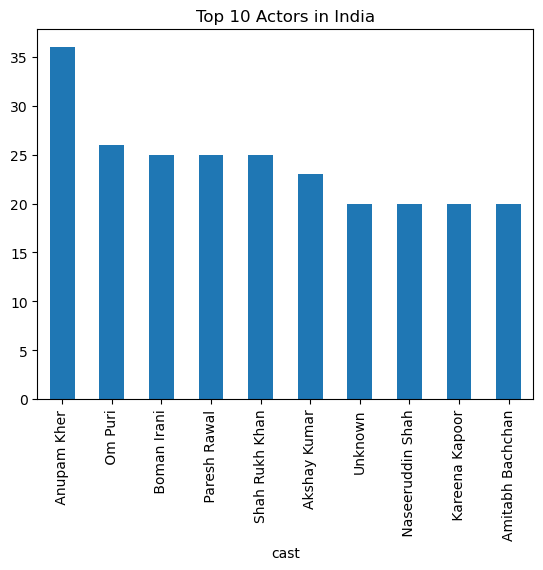

In [39]:
india_movies = df_sql[
    (df_sql['country'].str.contains("India", na=False)) &
    (df_sql['type'] == 'Movie')
]

actors = india_movies.assign(cast=india_movies['cast'].str.split(',')).explode('cast')

q14 = actors['cast'].value_counts().head(10)
print(q14)

q14.plot(kind='bar', title='Top 10 Actors in India')
plt.show()

15. Categorize Content (Kill/Violence)

category
Good    8465
Bad      342
Name: count, dtype: int64


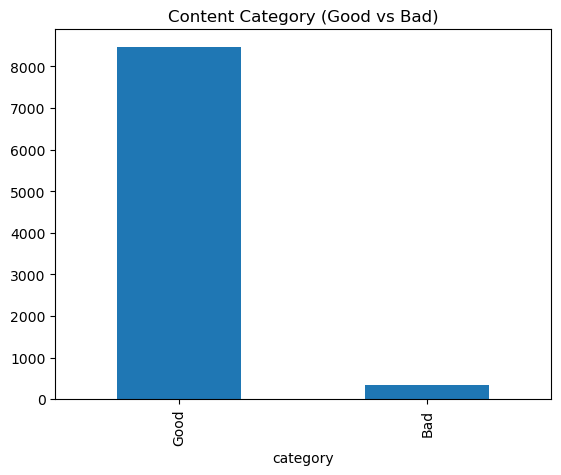

In [40]:
df_sql['category'] = df_sql['description'].str.lower().apply(
    lambda x: 'Bad' if ('kill' in x or 'violence' in x) else 'Good'
)

q15 = df_sql['category'].value_counts()
print(q15)

q15.plot(kind='bar', title='Content Category (Good vs Bad)')
plt.show()

In [ ]:
Used your SQL Server name
✔ Used the exact Excel path
✔ Included data cleaning
✔ Answered all 15 business problems
✔ Generated charts for each (auto-colored)
✔ Used real-world ETL + analytics approach